In [2]:
%config IPCompleter.greedy=True
import findspark
findspark.init()
from pyspark import SparkConf
from pyspark import SparkContext
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
conf=SparkConf().setMaster("local[*]").setAppName("Electronics Product Recommendation System")
sc = SparkContext.getOrCreate(conf=conf) 

In [4]:
dosya_yolu = "electronics.txt"
rdd = sc.textFile(dosya_yolu)
rdd.count()

1048576

In [5]:
# Verileri alanlara ayırma ve boşlukları temizleme
fields_rdd = rdd.map(lambda line: [field.strip() for field in line.split(';')])

# İstenmeyen sütunları kaldırma (user_attr ve split sütunları)
cleaned_rdd = fields_rdd.map(lambda fields: fields[:8])

# Dönüştürülmüş verileri doğrulama
sample_data = cleaned_rdd.take(16)  # İlk 5 kaydı al
for record in sample_data:
    print(record)

['item_id', 'user_id', 'rating', 'timestamp', 'model_attr', 'category', 'brand', 'year']
['0', '0', '5.0', '13.06.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '1', '5.0', '14.06.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '2', '3.0', '17.06.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '3', '1.0', '1.07.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '4', '2.0', '6.07.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '5', '2.0', '12.07.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '6', '5.0', '13.07.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '7', '2.0', '13.07.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '8', '4.0', '16.07.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '9', '5.0', '20.08.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '10', '1.0', '24.08.1999', 'Female', 'Portable Audio & Video', '', '1999']
['0', '11', '1.0', '4.10.1999', 

C:\Users\HP\AppData\Local\Temp\ipykernel_14472\2462535734.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_rated_items.index, y=most_rated_items.values, palette='viridis')


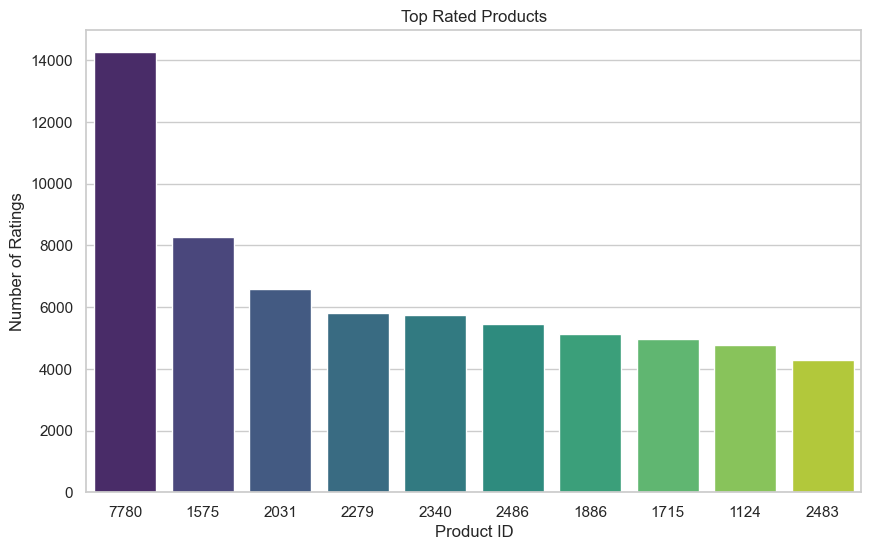

C:\Users\HP\AppData\Local\Temp\ipykernel_14472\2462535734.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_rated_categories.index, y=most_rated_categories.values, palette='viridis')


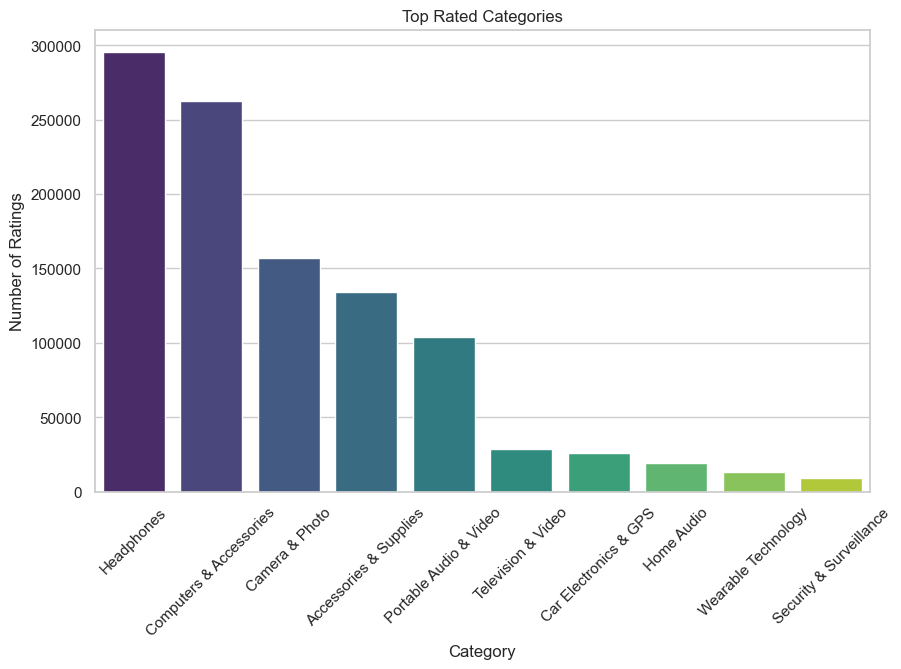

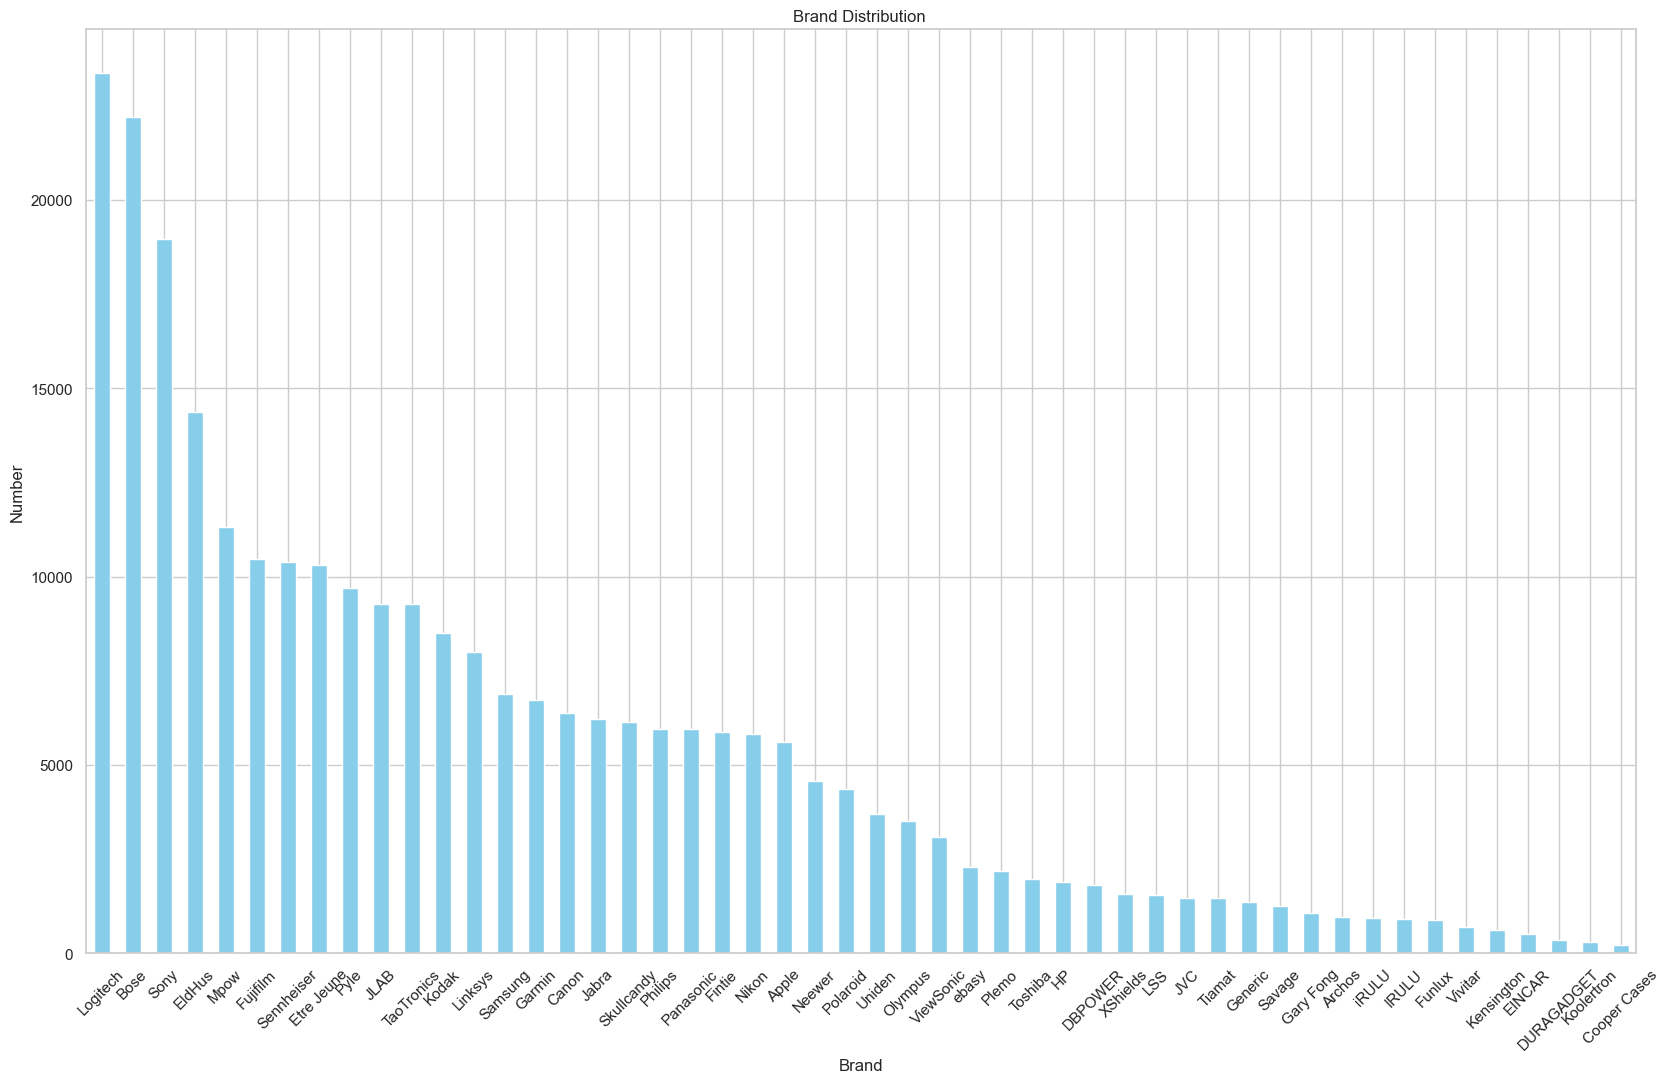

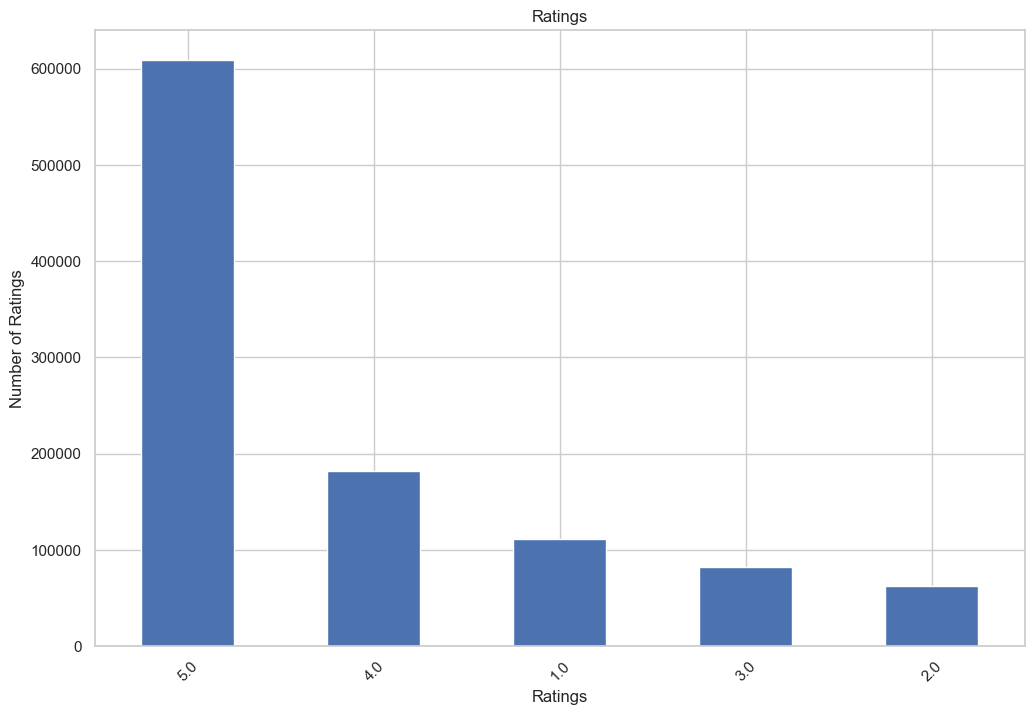

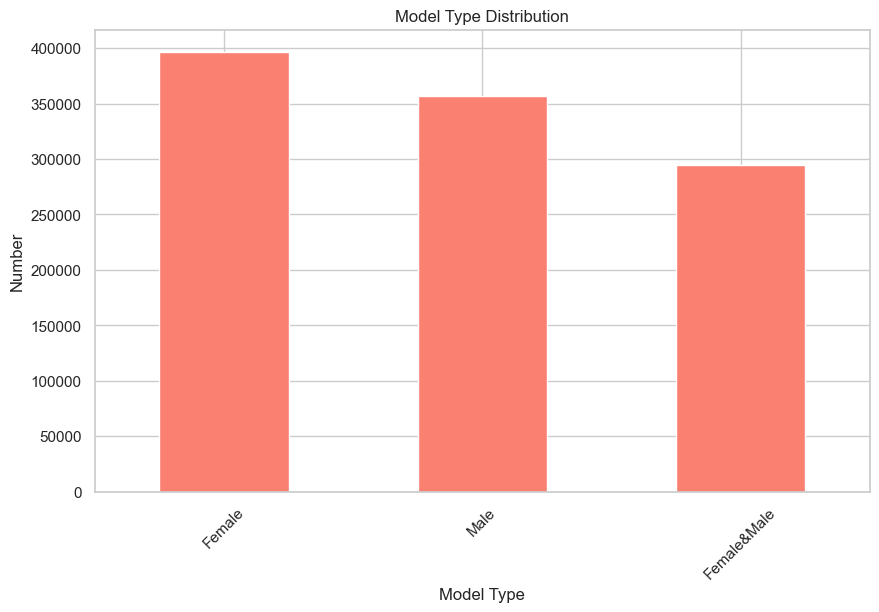

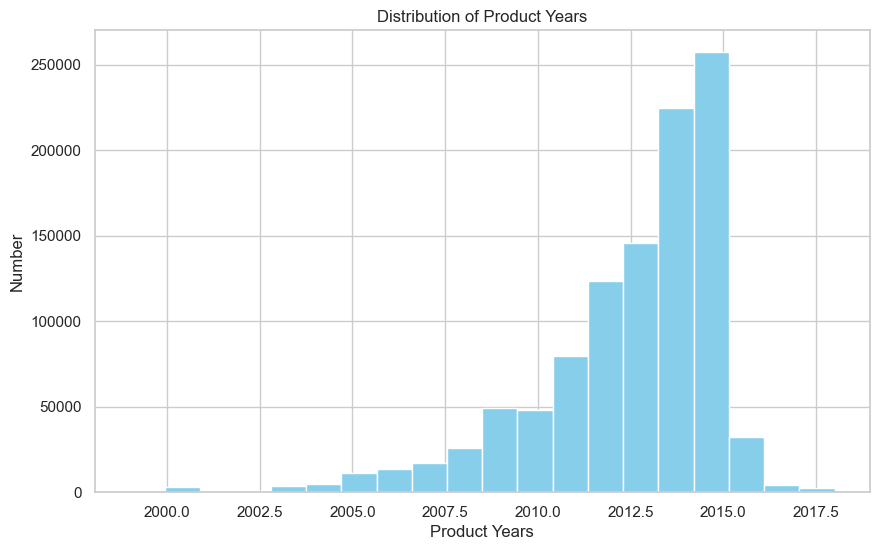

In [6]:

# Başlık satırını çıkarma
header = cleaned_rdd.first()
cleaned_data = cleaned_rdd.filter(lambda line: line != header)

# DataFrame oluşturma
columns = ['item_id', 'user_id','rating', 'timestamp', 'model_attr', 'category', 'brand', 'year']
df = pd.DataFrame(cleaned_data.collect(), columns=columns)

# Verilerin türlerini dönüştürme
df['rating'] = df['rating'].astype(float)
df['year'] = df['year'].astype(int)


# En çok puanlanan ürünleri ve kategorileri bulma
most_rated_items = df['item_id'].value_counts().head(10)
most_rated_categories = df['category'].value_counts().head(10)

# Görselleştirme
sns.set(style="whitegrid")

# En çok puanlanan ürünler
plt.figure(figsize=(10, 6))
sns.barplot(x=most_rated_items.index, y=most_rated_items.values, palette='viridis')
plt.title('Top Rated Products')
plt.xlabel('Product ID')
plt.ylabel('Number of Ratings')
plt.show()

# En çok puanlanan kategoriler
plt.figure(figsize=(10, 6))
sns.barplot(x=most_rated_categories.index, y=most_rated_categories.values, palette='viridis')
plt.title('Top Rated Categories')
plt.xlabel('Category')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.show()

import matplotlib.pyplot as plt

# Boş değerlere sahip satırları filtreleme
filtered_df = df[df['brand'] != '']

# Markaların dağılımı
plt.figure(figsize=(20, 12))
filtered_df['brand'].value_counts().plot(kind='bar', color='skyblue')
plt.xticks(rotation=45)
plt.title('Brand Distribution ')
plt.xlabel('Brand')
plt.ylabel('Number')
plt.show()


ratings = df['rating'].value_counts()
plt.figure(figsize=(12, 8))
ratings.plot(kind='bar')
plt.title('Ratings')
plt.xlabel('Ratings')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.show()



# Model türlerinin dağılımı
plt.figure(figsize=(10, 6))
df['model_attr'].value_counts().plot(kind='bar', color='salmon')
plt.title('Model Type Distribution')
plt.xlabel('Model Type')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
df['year'].plot(kind='hist', bins=20, color='skyblue')

plt.title('Distribution of Product Years')
plt.xlabel('Product Years')
plt.ylabel('Number')
plt.show()

In [7]:
# Rating sütununun değerlerini float'a dönüştürme
ratings = cleaned_data.map(lambda x: float(x[2]))

# Rating sütununun değerlerini toplamak
rating_values = ratings.collect()

# Median hesaplama
n = len(rating_values)
sorted_ratings = sorted(rating_values)
median = (sorted_ratings[n // 2] + sorted_ratings[(n - 1) // 2]) / 2 if n % 2 == 0 else sorted_ratings[n // 2]
rating_count = ratings.count()
# Rating değerlerinin toplamını bulma
rating_sum = ratings.reduce(lambda x, y: x + y)

# Ortalama hesaplama
rating_mean = rating_sum / rating_count

# Rating istatistiklerini ekrana yazdırma
print("Rating Statistics:")
print(f"Rating Count: {rating_count}")
print(f"Mean: {rating_mean}")
print(f"Median: {median}")


Rating Statistics:
Rating Count: 1048575
Mean: 4.062871992942803
Median: 5.0


In [8]:
# Her markaya ait puanların toplamını ve sayısını hesapla
brand_ratings = cleaned_data.filter(lambda x: x[6] != '') \
                            .map(lambda x: (x[6], (float(x[2]), 1))) \
                            .reduceByKey(lambda x, y: (x[0] + y[0], x[1] + y[1]))

# Her markaya ait ortalama puanı hesapla
brand_avg_ratings = brand_ratings.map(lambda x: (x[0], x[1][0] / x[1][1]))

# Sonuçları göster
print("Brand - Average Rating:")
for brand, avg_rating in brand_avg_ratings.collect():
    print(f"{brand}: {avg_rating}")


Brand - Average Rating:
HP: 3.8137931034482757
Philips: 3.8055089015787704
Polaroid: 3.7985347985347984
JVC: 3.887381275440977
Nikon: 3.982666895486528
Sony: 4.171687859441777
Canon: 4.249019300172603
Pyle: 3.644320873236536
Vivitar: 3.5708215297450425
Sennheiser: 4.093575687632237
Apple: 4.398608881754949
Garmin: 4.186783747581486
Gary Fong: 4.137037037037037
ViewSonic: 3.7277723892660846
Savage: 4.592828685258964
Neewer: 4.387350054525627
iRULU: 3.5063559322033897
Tiamat: 4.592896174863388
Fintie: 4.493012951601909
EINCAR: 3.169230769230769
Cooper Cases: 4.277777777777778
LSS: 3.8490687219010917
XShields: 3.904911838790932
IRULU: 3.3767643865363737
Funlux: 3.44
Panasonic: 4.2258118795221264
Fujifilm: 4.344158945458019
Kodak: 3.75579889320617
Kensington: 3.961102106969206
Olympus: 4.140985474223868
Toshiba: 3.996978851963746
Logitech: 4.150171232876712
Etre Jeune: 4.314798641436196
Linksys: 3.5174956260934764
Samsung: 4.020360674810936
EldHus: 4.2455127313204395
Bose: 4.34286357496623

Rank: 5, Iteration: 5, Lambda: 0.01, RMSE: 3.12585102688211, MSE: 9.77094464225995
Rank: 5, Iteration: 5, Lambda: 0.1, RMSE: 3.1302605502660965, MSE: 9.798531112552205
Rank: 5, Iteration: 10, Lambda: 0.01, RMSE: 3.129721268764768, MSE: 9.795155220158543
Rank: 5, Iteration: 10, Lambda: 0.1, RMSE: 3.112365062875638, MSE: 9.686816284608874
Rank: 5, Iteration: 15, Lambda: 0.01, RMSE: 3.1290259369037705, MSE: 9.790803313816516
Rank: 5, Iteration: 15, Lambda: 0.1, RMSE: 3.100296076301874, MSE: 9.611835760732793
Rank: 10, Iteration: 5, Lambda: 0.01, RMSE: 3.1975961380550735, MSE: 10.224621062104715
Rank: 10, Iteration: 5, Lambda: 0.1, RMSE: 3.226260304031178, MSE: 10.408755549367347
Rank: 10, Iteration: 10, Lambda: 0.01, RMSE: 3.2035900405939435, MSE: 10.262989148192705
Rank: 10, Iteration: 10, Lambda: 0.1, RMSE: 3.234099825887874, MSE: 10.459401683807977
Rank: 10, Iteration: 15, Lambda: 0.01, RMSE: 3.2076492621800496, MSE: 10.289013789164215
Rank: 10, Iteration: 15, Lambda: 0.1, RMSE: 3.2331

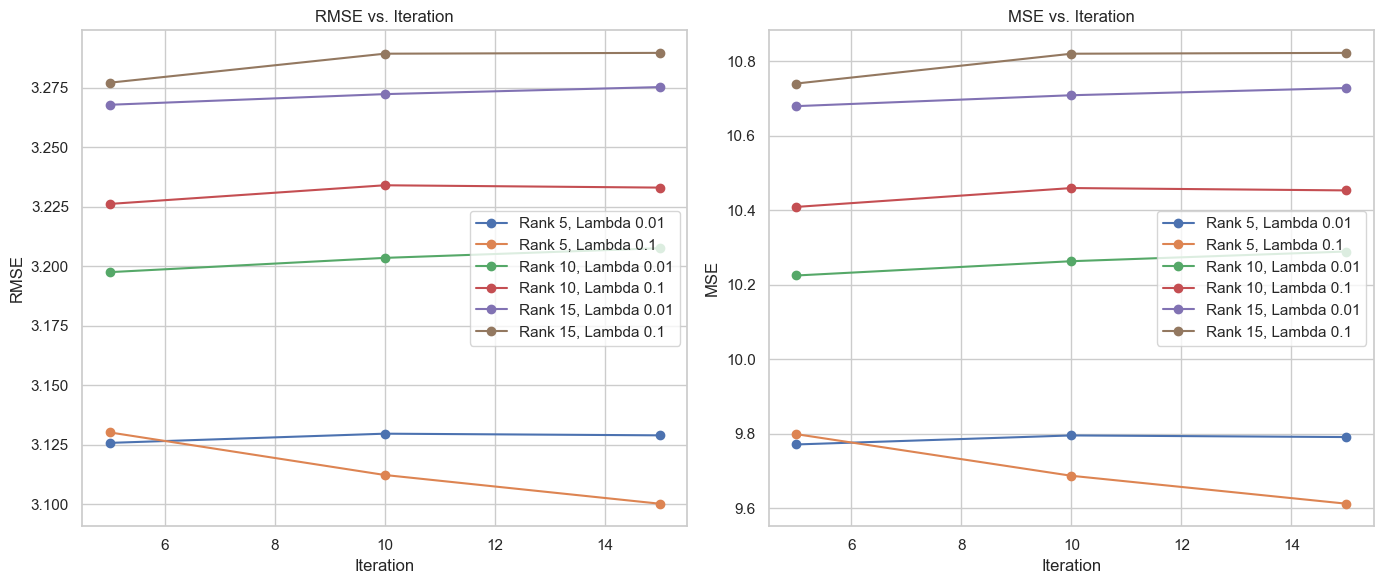

In [9]:
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.sql.functions import col, unix_timestamp
from pyspark.sql.types import TimestampType
import matplotlib.pyplot as plt
from pyspark.sql.functions import expr
# Spark oturumunu başlat ve bellek ayarlarını yap
spark = SparkSession.builder \
    .appName("ElectronicsProductRecommendationSystem") \
    .config("spark.executor.memory", "1g") \
    .config("spark.driver.memory", "1g") \
    .getOrCreate()
spark_df = spark.createDataFrame(df)

# Veri setinin %10'unu örnekleme
sampled_df = spark_df.sample(withReplacement=False,fraction=0.1, seed=1234)

# Veri tiplerini dönüştürme
sampled_df = sampled_df.withColumn('rating', col('rating').cast('int'))
sampled_df = sampled_df.withColumn('year', col('year').cast('int'))
sampled_df = sampled_df.withColumn('user_id', col('user_id').cast('int'))
sampled_df = sampled_df.withColumn('item_id', col('item_id').cast('int'))
sampled_df = sampled_df.withColumn('timestamp', unix_timestamp(col('timestamp'), 'yyyy-MM-dd HH:mm:ss').cast(TimestampType()))

# Veriyi eğitim ve test kümelerine ayırma (%70 eğitim, %30 test)
(training, test) = sampled_df.randomSplit([0.7, 0.3], seed=5030)

# ALS modeli parametreleri
ranks = [5,10, 15]
iterations = [5,10, 15]
lambdas = [0.01, 0.1]
results = []

# Tüm parametre kombinasyonları üzerinde döngü
for rank in ranks:
    for iteration in iterations:
        for lambda_ in lambdas:
            # ALS modelini oluşturma
            als = ALS(rank=rank, maxIter=iteration, regParam=lambda_, userCol="user_id", itemCol="item_id", ratingCol="rating", coldStartStrategy="drop", seed=5030)
            
            # ALS modelini eğitim verisi ile eğit
            model = als.fit(training)
            
            # Modeli test verisi üzerinde değerlendir
            predictions = model.transform(test)
            predictions = predictions.withColumn("prediction", expr("CASE WHEN prediction < 1 THEN 1 WHEN prediction > 5 THEN 5 ELSE prediction END"))
            # RMSE (Kök Ortalama Kare Hatası) hesaplama
            evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
            rmse = evaluator.evaluate(predictions)
            
            # MSE (Ortalama Kare Hatası) hesaplama
            mse_evaluator = RegressionEvaluator(metricName="mse", labelCol="rating", predictionCol="prediction")
            mse = mse_evaluator.evaluate(predictions)

            results.append((rank, iteration, lambda_, rmse, mse))
            # Sonuçları yazdırma
            print(f"Rank: {rank}, Iteration: {iteration}, Lambda: {lambda_}, RMSE: {rmse}, MSE: {mse}")

# Sonuçları bir DataFrame'e dönüştür
results_df = spark.createDataFrame(results, ["Rank", "Iteration", "Lambda", "RMSE", "MSE"])

# PySpark DataFrame'i pandas DataFrame'e dönüştür
results_pd = results_df.toPandas()

# RMSE ve MSE'yi çizdir
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

for rank in ranks:
    subset = results_pd[results_pd['Rank'] == rank]
    for lambda_ in lambdas:
        lambda_subset = subset[subset['Lambda'] == lambda_]
        plt.plot(lambda_subset['Iteration'], lambda_subset['RMSE'], marker='o', label=f'Rank {rank}, Lambda {lambda_}')
plt.title('RMSE vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.legend()

plt.subplot(1, 2, 2)
for rank in ranks:
    subset = results_pd[results_pd['Rank'] == rank]
    for lambda_ in lambdas:
        lambda_subset = subset[subset['Lambda'] == lambda_]
        plt.plot(lambda_subset['Iteration'], lambda_subset['MSE'], marker='o', label=f'Rank {rank}, Lambda {lambda_}')
plt.title('MSE vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.sql.functions import col, unix_timestamp, round
from pyspark.sql.types import TimestampType
from pyspark.sql.functions import when
from pyspark.sql.functions import expr
# Spark oturumunu başlat ve bellek ayarlarını yap
spark = SparkSession.builder \
    .appName("ElectronicsProductRecommendationSystem") \
    .config("spark.executor.memory", "1g") \
    .config("spark.driver.memory", "1g") \
    .getOrCreate()


# Pandas DataFrame'i Spark DataFrame'e dönüştür
spark_df = spark.createDataFrame(df)

# Veri setinin tamamını alıyoruz
sampled_df = spark_df.sample(fraction=1.0, seed=5030)

# Veri tiplerini dönüştürme
sampled_df = sampled_df.withColumn('rating', col('rating').cast('int'))
sampled_df = sampled_df.withColumn('year', col('year').cast('int'))
sampled_df = sampled_df.withColumn('user_id', col('user_id').cast('int'))
sampled_df = sampled_df.withColumn('item_id', col('item_id').cast('int'))
sampled_df = sampled_df.withColumn('timestamp', unix_timestamp(col('timestamp'), 'yyyy-MM-dd HH:mm:ss').cast(TimestampType()))

# Veriyi eğitim ve test kümelerine ayırma (%70 eğitim, %30 test)
(training, test) = sampled_df.randomSplit([0.7, 0.3], seed=5030)

# En iyi ALS modeli parametreleri
rank = 5
maxIter = 15
regParam = 0.1

# ALS modelini oluşturma
als = ALS(rank=rank, maxIter=maxIter, regParam=regParam, userCol="user_id", itemCol="item_id", ratingCol="rating", coldStartStrategy="drop", seed=5030)

# ALS modelini eğitim verisi ile eğit
model = als.fit(training)

# Modeli test verisi üzerinde değerlendir
predictions = model.transform(test)

# Tahminleri ve gerçek değerleri yan yana gösterme

predictions = predictions.withColumn("prediction",round(expr("CASE WHEN prediction < 1 THEN 1 WHEN prediction > 5 THEN 5 ELSE prediction END"),2))
predictions.select("user_id", "item_id", "rating", "prediction").show(10)

# RMSE (Kök Ortalama Kare Hatası) hesaplama
rmse_evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = rmse_evaluator.evaluate(predictions)

# MSE (Ortalama Kare Hatası) hesaplama
mse_evaluator = RegressionEvaluator(metricName="mse", labelCol="rating", predictionCol="prediction")
mse = mse_evaluator.evaluate(predictions)

print(f"RMSE: {rmse}")
print(f"MSE: {mse}")


+-------+-------+------+----------+
|user_id|item_id|rating|prediction|
+-------+-------+------+----------+
|     28|    840|     5|      2.45|
|     28|   1776|     3|      2.44|
|     81|    536|     5|       1.0|
|    392|   1111|     1|      3.75|
|    516|     46|     2|       1.0|
|    950|     72|     2|       1.0|
|   1156|   1919|     5|      4.04|
|   1156|   4718|     5|       5.0|
|   1226|     39|     5|       1.0|
|   1265|   1148|     5|       1.0|
+-------+-------+------+----------+
only showing top 10 rows

RMSE: 2.8396177919096655
MSE: 8.063429204129925


In [16]:
import numpy as np
from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, IntegerType, FloatType
from pyspark.sql.functions import col
import pyspark.sql.functions as F
# Kullanıcı ve ürün faktörlerini alın
user_factors = model.userFactors
item_factors = model.itemFactors

# Ürün X için faktörleri alın
product_x_id = 1278  # Değiştirebileceğimiz ürün ID'si
product_x_factors = item_factors.filter(col("id") == product_x_id).select("features").collect()

if len(product_x_factors) > 0:
    product_x_factors = np.array(product_x_factors[0].features)
    
    # Cosine benzerliği hesaplama
    def cosine_similarity(features, product_x_factors):
        user_factors = np.array(features)
        dot_product = np.dot(user_factors, product_x_factors)
        norm_user = np.linalg.norm(user_factors)
        norm_product = np.linalg.norm(product_x_factors)
        similarity = dot_product / (norm_user * norm_product)
        return float(similarity)
    
    cosine_similarity_udf = F.udf(lambda x: cosine_similarity(x, product_x_factors), FloatType())
    
    # Kullanıcı faktörleri ile cosine benzerliklerini hesaplayın
    user_similarities = user_factors.withColumn("similarity", cosine_similarity_udf(col("features")))
    
    # En yüksek benzerliklere sahip 10 kullanıcıyı bulun
    top_10_users = user_similarities.orderBy(col("similarity").desc()).limit(40)
    top_10_users.show()
else:
    print(f"Product with ID {product_x_id} not found.")


+------+--------------------+----------+
|    id|            features|similarity|
+------+--------------------+----------+
| 54814|[0.242767, -0.863...|       1.0|
| 40479|[0.0971068, -0.34...|       1.0|
| 41242|[0.1942136, -0.69...|       1.0|
| 38260|[0.1942136, -0.69...|       1.0|
|446221|[0.12204156, -1.0...|0.89574414|
|558329|[0.19766797, -1.5...| 0.8784059|
|379373|[-0.19254297, -1....|0.87614787|
| 56370|[0.31572565, -0.9...|0.85299456|
|634071|[-0.08333541, -0....| 0.8503141|
|678579|[0.12074261, -1.2...|0.84896034|
|556208|[0.12074261, -1.2...|0.84896034|
|353079|[0.12074261, -1.2...|0.84896034|
|248022|[0.12074261, -1.2...|0.84896034|
|864499|[0.12074261, -1.2...|0.84896034|
|214018|[0.12074261, -1.2...|0.84896034|
|674219|[0.12074261, -1.2...|0.84896034|
|388610|[0.12074261, -1.2...|0.84896034|
|688639|[0.12074261, -1.2...|0.84896034|
|686388|[0.072445564, -0....|0.84896034|
|376032|[0.12074261, -1.2...|0.84896034|
+------+--------------------+----------+
only showing top